# **Forecasting weekly German electricity demand**

- **Block I** — Data and stationarity (Part 1)
- **Block II** — Benchmark forecasts (Part 2)
- **Block III** — SARIMA model (Part 3)
- **Block IV** — SARIMAX with temperature (Part 4)
- **Block V** — Feature-based machine learning (Part 5)
- **Block VI** — LSTM on hourly demand (Part 6)
- **Block VII** — Analysis questions (Part 7)
- **Block VIII** — Consolidated comparison (Part 8)
- **Block IX** — Repository notes (Part 9)


In [1]:
# The install cell is safe to re-run. It pins nothing so it stays Colab-friendly.
import sys, subprocess

def _pip_m7(*pkgs):
    # This helper installs quietly and never aborts the notebook on a failed optional
    # package, which keeps the run reproducible across environments.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

_pip_m7("numpy", "pandas", "matplotlib", "statsmodels", "scikit-learn", "requests", "holidays", "joblib")
# TensorFlow is heavier; it is installed on a best-effort basis for the LSTM block.
_pip_m7("tensorflow")
print("Environment setup cell finished.")


Environment setup cell finished.


## Imports, deterministic seeds and the plotting style

In [2]:
import os, io, hashlib, warnings, types, math, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# A single global seed drives NumPy and, later, TensorFlow so the whole notebook is
# reproducible from a fresh kernel.
GLOBAL_SEED = 57
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Convergence chatter from the SARIMA grid is expected and is silenced so the output
# stays readable; genuine errors still surface.
warnings.filterwarnings("ignore")


def pick_style(style_key="axis_seed_57"):
    # This function turns a neutral text key into a reproducible visual identity. The
    # numeric parameters come from a SHA-256 seed so they are stable and collision-free,
    # while the palette expresses the intended indigo-lime colour theme.
    seed = int(hashlib.sha256(style_key.encode()).hexdigest()[:8], 16)
    figw = 10 + seed % 4
    line_width = 1.4 + (seed % 5) * 0.15
    title_upper = (seed // 5) % 2 == 0
    palette = {
        "primary": "#3730a3",   # indigo
        "accent": "#84cc16",     # lime
        "actual": "#111827",     # near-black for the observed series
        "band": "#c7d2fe",       # soft indigo for interval shading
        "warm": "#ea580c",       # contrast colour for a secondary model
        "cool": "#0891b2",       # teal contrast colour
    }
    cycle = ["#3730a3", "#84cc16", "#ea580c", "#0891b2", "#a21caf", "#ca8a04"]
    return types.SimpleNamespace(
        key=style_key,
        seed=seed,
        palette=palette,
        cycle=cycle,
        figsize=(figw, 4.6),
        line_width=round(line_width, 3),
        title_upper=title_upper,
        mpl_style="seaborn-v0_8-darkgrid",
        font_family="sans-serif",
        font_pref=["Nimbus Sans", "DejaVu Sans", "sans-serif"],
    )


STYLE = pick_style("axis_seed_57")

# The style is applied globally so every figure inherits it.
try:
    plt.style.use(STYLE.mpl_style)
except Exception:
    plt.style.use("ggplot")
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=STYLE.cycle)
mpl.rcParams["font.family"] = STYLE.font_family
mpl.rcParams["font.sans-serif"] = STYLE.font_pref
mpl.rcParams["figure.figsize"] = STYLE.figsize
mpl.rcParams["lines.linewidth"] = STYLE.line_width
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11


def styled_title(text):
    # The title case is derived from the style seed; this keeps the notebook's
    # presentation consistent throughout.
    return text.upper() if STYLE.title_upper else text


print("Style key:", STYLE.key, "| seed:", STYLE.seed, "| figsize:", STYLE.figsize,
      "| line width:", STYLE.line_width)


Style key: axis_seed_57 | seed: 3716783117 | figsize: (11, 4.6) | line width: 1.7


## Fixed modelling choices

In [3]:
# The weekly mean is taken with a Friday-anchored week. A weekly mean is still a
# weekly mean; the anchor simply fixes which seven days fall together.
WEEK_ANCHOR = "W-FRI"
SEASON_LENGTH = 52          # annual seasonality on the weekly series
TEST_WEEKS = 104            # the final two years form the test window
MIN_HOURS_PER_WEEK = 160    # weeks with fewer hours are treated as partial and dropped
HDD_BASE = 15.0             # heating degree-day base temperature in degrees Celsius
CDD_BASE = 22.5             # cooling degree-day base temperature in degrees Celsius
FEATURE_LAGS = [1, 4, 13, 52]      # target lags fed to the tree models
ROLLING_WINDOWS = [8, 26]          # rolling-mean windows fed to the tree models
LOOK_BACK = 168             # LSTM look-back window in hours (one week)

# The data path is relative so the notebook is portable. The download cell fills it in
# if the file is absent.
DATA_FILE = "time_series_60min_singleindex.csv"
TEMP_CACHE = "berlin_daily_temperature.csv"
LOAD_COLUMN = "DE_load_actual_entsoe_transparency"

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
print("Weekly anchor:", WEEK_ANCHOR, "| season length:", SEASON_LENGTH,
      "| test window:", TEST_WEEKS, "weeks")


Weekly anchor: W-FRI | season length: 52 | test window: 104 weeks


## **Block I  Data & stationarity (Part 1)**

In [4]:
# The acquisition step prefers the local file and falls back to the public download so
# the notebook runs unattended in Colab.
import requests

OPSD_URL = ("https://data.open-power-system-data.org/time_series/2020-10-06/"
            "time_series_60min_singleindex.csv")

if not os.path.exists(DATA_FILE):
    print("Local data not found; downloading the Open Power System Data 60-minute file.")
    try:
        with requests.get(OPSD_URL, stream=True, timeout=120) as resp:
            resp.raise_for_status()
            with open(DATA_FILE, "wb") as handle:
                for chunk in resp.iter_content(chunk_size=1 << 20):
                    handle.write(chunk)
        print("Download complete.")
    except Exception as exc:
        raise RuntimeError(
            "Could not obtain the data file. Place time_series_60min_singleindex.csv "
            "in the notebook folder and re-run."
        ) from exc
else:
    print("Using the local data file:", DATA_FILE)


Local data not found; downloading the Open Power System Data 60-minute file.
Download complete.


### Weekly and daily binning

In [5]:
def shape_weekly(hourly_gw, anchor=WEEK_ANCHOR, min_hours=MIN_HOURS_PER_WEEK):
    # This function aggregates an hourly gigawatt series to weekly means for a given week
    # anchor and drops boundary weeks that do not contain enough hours, so the weekly
    # summary statistics are not skewed by half-populated weeks.
    grouped = hourly_gw.resample(anchor)
    weekly_mean = grouped.mean()
    hours_present = grouped.count()
    full_weeks = hours_present >= min_hours
    return weekly_mean[full_weeks]


# We read only the two needed columns and parse the timestamp as the index.
raw = pd.read_csv(
    DATA_FILE,
    usecols=["utc_timestamp", LOAD_COLUMN],
    parse_dates=["utc_timestamp"],
    index_col="utc_timestamp",
)

# The 2015 slice is applied on the UTC index before converting to Berlin local time so
# no hour is dropped at the boundary.
series_utc = raw[LOAD_COLUMN].loc["2015-01-01":]
series_local = series_utc.tz_convert("Europe/Berlin").tz_localize(None)

# Short gaps are filled by time interpolation; megawatts are converted to gigawatts.
series_local = series_local.interpolate(method="time", limit=6)
hourly_load = (series_local / 1000.0).dropna()
hourly_load.name = "load_gw"

# The weekly and daily mean series follow from the cleaned hourly series.
weekly_load = shape_weekly(hourly_load)
weekly_load.name = "load_gw"
daily_load = hourly_load.resample("D").mean()
daily_load.name = "load_gw"

print("Hourly observations:", len(hourly_load))
print("Weekly observations:", len(weekly_load),
      "from", weekly_load.index.min().date(), "to", weekly_load.index.max().date())
print("Daily observations:", len(daily_load))
weekly_load.describe().round(3)


Hourly observations: 50400
Weekly observations: 299 from 2015-01-09 to 2020-09-25
Daily observations: 2101


,load_gw
count,299.000
mean,55.505
std,3.747
min,45.995
25%,52.950
50%,54.893
75%,58.691
max,63.311


### Exploratory plots

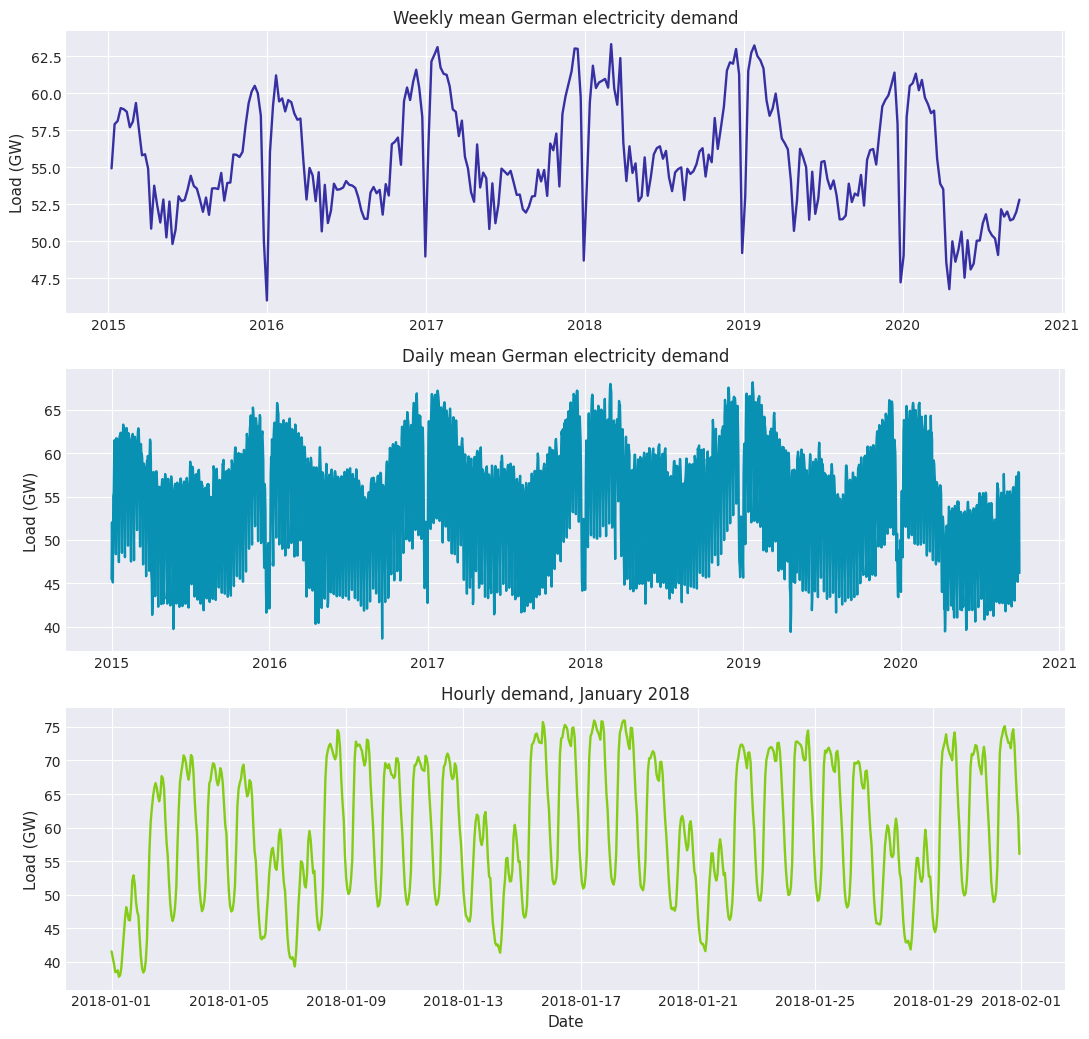

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(STYLE.figsize[0], 10.5))

axes[0].plot(weekly_load.index, weekly_load.values, color=STYLE.palette["primary"])
axes[0].set_title(styled_title("Weekly mean German electricity demand"))
axes[0].set_ylabel("Load (GW)")

axes[1].plot(daily_load.index, daily_load.values, color=STYLE.palette["cool"])
axes[1].set_title(styled_title("Daily mean German electricity demand"))
axes[1].set_ylabel("Load (GW)")

one_month = hourly_load.loc["2018-01-01":"2018-01-31"]
axes[2].plot(one_month.index, one_month.values, color=STYLE.palette["accent"])
axes[2].set_title(styled_title("Hourly demand, January 2018"))
axes[2].set_ylabel("Load (GW)")
axes[2].set_xlabel("Date")

fig.tight_layout()
plt.show()


### Seasonal decomposition

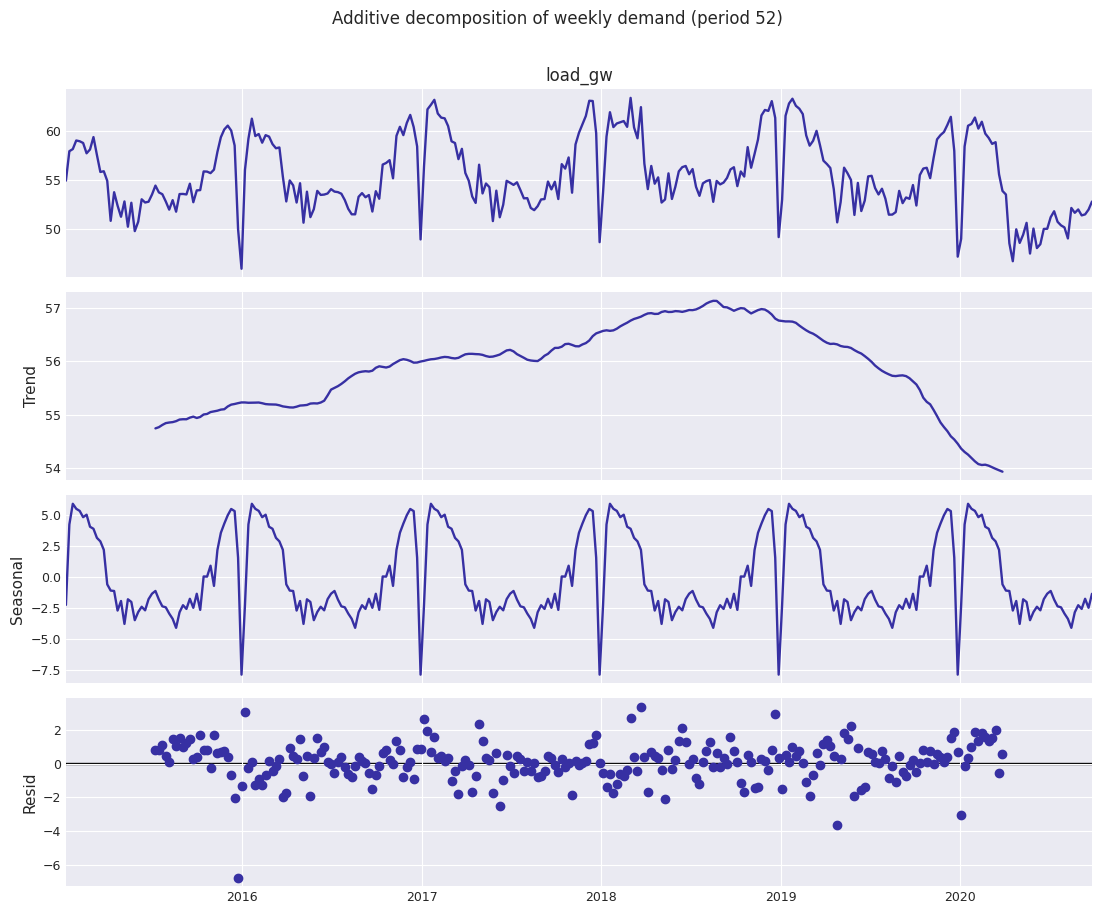

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly_load, model="additive", period=SEASON_LENGTH)
fig = decomposition.plot()
fig.set_size_inches(STYLE.figsize[0], 9)
for ax in fig.axes:
    ax.tick_params(labelsize=9)
fig.suptitle(styled_title("Additive decomposition of weekly demand (period 52)"), y=1.01)
fig.tight_layout()
plt.show()


### Stationarity battery

In [8]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def adf_scan(series_map):
    # This function runs the ADF test over a dictionary of named series and returns a
    # tidy table of test statistics and p-values. The result is indexed positionally so
    # it works regardless of the statsmodels return signature.
    rows = []
    for name, values in series_map.items():
        clean = pd.Series(values).dropna()
        result = adfuller(clean, autolag="AIC")
        rows.append({"series": name, "adf_stat": result[0], "p_value": result[1],
                     "n_used": result[3]})
    return pd.DataFrame(rows).set_index("series")


level = weekly_load
first_diff = weekly_load.diff()
seasonal_diff = weekly_load.diff(SEASON_LENGTH)
both_diff = weekly_load.diff().diff(SEASON_LENGTH)

adf_table = adf_scan({
    "level": level,
    "first difference (d=1)": first_diff,
    "seasonal difference (D=1, s=52)": seasonal_diff,
    "first + seasonal difference": both_diff,
})
adf_table.round(5)


,adf_stat,p_value,n_used
series,,,
level,-3.86726,0.00229,290
first difference (d=1),-7.09799,0.00000,290
"seasonal difference (D=1, s=52)",-2.46668,0.12379,239
first + seasonal difference,-7.11772,0.00000,233


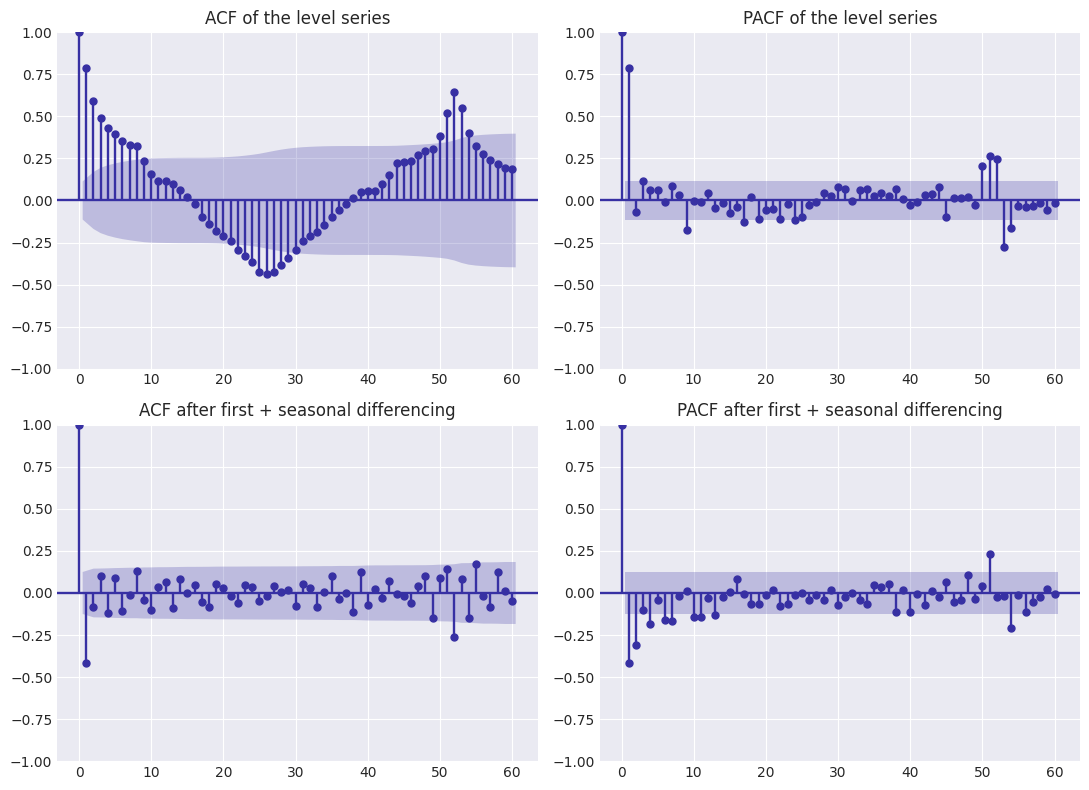

In [9]:
# The ACF and PACF are shown on the level and on the doubly differenced series so the
# seasonal structure and its removal are both visible.
fig, axes = plt.subplots(2, 2, figsize=(STYLE.figsize[0], 8))
plot_acf(level.dropna(), ax=axes[0, 0], lags=60)
axes[0, 0].set_title(styled_title("ACF of the level series"))
plot_pacf(level.dropna(), ax=axes[0, 1], lags=60, method="ywm")
axes[0, 1].set_title(styled_title("PACF of the level series"))
plot_acf(both_diff.dropna(), ax=axes[1, 0], lags=60)
axes[1, 0].set_title(styled_title("ACF after first + seasonal differencing"))
plot_pacf(both_diff.dropna(), ax=axes[1, 1], lags=60, method="ywm")
axes[1, 1].set_title(styled_title("PACF after first + seasonal differencing"))
fig.tight_layout()
plt.show()


### Train and test split

In [10]:
# The split is strictly time-ordered: the last 104 weeks are held out.
ytrain = weekly_load.iloc[:-TEST_WEEKS]
ytest = weekly_load.iloc[-TEST_WEEKS:]
pred = {}   # every model deposits its 104-week forecast here, keyed by model name

print("Train weeks:", len(ytrain), "| test weeks:", len(ytest))
print("Test window:", ytest.index.min().date(), "to", ytest.index.max().date())


Train weeks: 195 | test weeks: 104
Test window: 2018-10-05 to 2020-09-25


### Evaluation metrics

In [11]:
def _mase_scale_m7(train):
    # The MASE scale is the mean absolute seasonal difference of the training series,
    # i.e. the in-sample error of a seasonal-naive forecast.
    return np.mean(np.abs(pd.Series(train).diff(SEASON_LENGTH).dropna()))


MASE_SCALE = _mase_scale_m7(ytrain)


def tally(actual, forecast, scale=MASE_SCALE):
    # This function returns the four required metrics for one forecast on the test window.
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = forecast - actual
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mase = mae / scale
    bias = np.mean(error)
    return {"MAE": mae, "RMSE": rmse, "MASE": mase, "Bias": bias}


def coverage(actual, lower, upper):
    # This function returns the empirical coverage of a prediction interval, the share of
    # test actuals that fall between the lower and upper bounds.
    actual = np.asarray(actual, dtype=float)
    inside = (actual >= np.asarray(lower, dtype=float)) & (actual <= np.asarray(upper, dtype=float))
    return float(np.mean(inside))


# Self-check: a forecast equal to the actuals must score MASE exactly zero.
_perfect = tally(ytest.values, ytest.values)
assert abs(_perfect["MASE"]) < 1e-12, "MASE self-check failed"
print("MASE self-check passed (perfect forecast scores 0).")
print("MASE scale (in-sample seasonal-naive MAE):", round(MASE_SCALE, 4), "GW")


MASE self-check passed (perfect forecast scores 0).
MASE scale (in-sample seasonal-naive MAE): 1.385 GW


## **Block II  Benchmark forecasts (Part 2)**.

In [12]:
def benchmark_bundle(train, horizon, season=SEASON_LENGTH):
    # This function returns the four benchmark forecasts as a dictionary of arrays, each
    # of the requested horizon length. Naming it distinctly keeps the workspace tidy.
    train = pd.Series(train)
    last = train.iloc[-1]
    out = {}
    out["mean"] = np.repeat(train.mean(), horizon)
    out["naive"] = np.repeat(last, horizon)
    # The seasonal-naive forecast repeats the final season and tiles it over the horizon.
    last_season = train.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    out["seasonal_naive"] = np.tile(last_season, reps)[:horizon]
    # The drift line extrapolates the average step change seen in training.
    slope = (last - train.iloc[0]) / (len(train) - 1)
    out["drift"] = last + slope * np.arange(1, horizon + 1)
    return out


# The benchmark forecasts are computed once and stored on the shared prediction index.
bench_forecasts = benchmark_bundle(ytrain, TEST_WEEKS)
for name, values in bench_forecasts.items():
    pred[name] = pd.Series(values, index=ytest.index)

bench_metrics = {name: tally(ytest.values, pred[name].values) for name in bench_forecasts}
pd.DataFrame(bench_metrics).T.round(4)


,MAE,RMSE,MASE,Bias
mean,3.7855,4.3960,2.7332,0.5555
naive,3.8906,4.5074,2.8092,1.1402
seasonal_naive,2.3060,3.0450,1.6650,1.7368
drift,4.0593,4.7229,2.9310,1.5092


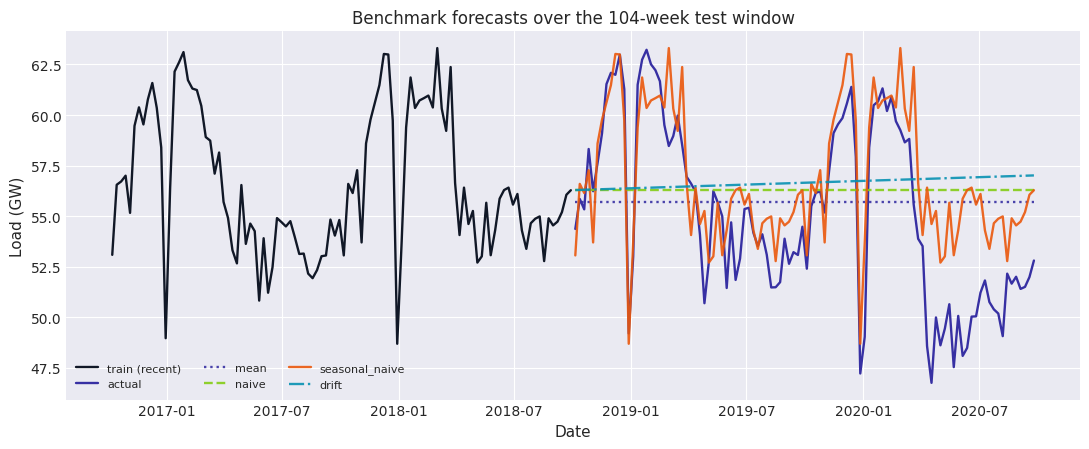

In [13]:
fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.plot(ytrain.index[-104:], ytrain.values[-104:], color=STYLE.palette["actual"],
        label="train (recent)")
ax.plot(ytest.index, ytest.values, color=STYLE.palette["primary"], label="actual")
styles = {"mean": ":", "naive": "--", "seasonal_naive": "-", "drift": "-."}
for name in ["mean", "naive", "seasonal_naive", "drift"]:
    ax.plot(ytest.index, pred[name].values, linestyle=styles[name], label=name, alpha=0.9)
ax.set_title(styled_title("Benchmark forecasts over the 104-week test window"))
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()


## **Block III  SARIMA model (Part 3)**

In [ ]:
import itertools, warnings
from joblib import Parallel, delayed
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# FAST = True narrows p,q to [0,3] for quick iteration only. The submission run must
# use the full grid, so FAST stays False here.
FAST = False
P_RANGE = range(0, 4) if FAST else range(0, 7)
Q_RANGE = range(0, 4) if FAST else range(0, 7)
D_RANGE = range(0, 3)
SEASONAL_ORDER = (1, 1, 1, SEASON_LENGTH)
SCREEN_MAXITER = 120   # bounded optimiser budget for the screening stage only


def _screen_fit_m7(train, order, seasonal_order, maxiter=SCREEN_MAXITER):

    warnings.filterwarnings("ignore")
    try:
        fitted = SARIMAX(
            train, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False, maxiter=maxiter)
        return order, float(fitted.aic)
    except Exception:
        return order, float("inf")


def sarima_search(train, p_range, d_range, q_range, seasonal_order):

    orders = list(itertools.product(p_range, d_range, q_range))
    total = len(orders)
    n_jobs = os.cpu_count() or 1
    chunk_size = max(n_jobs, 8)
    print(f"SARIMA screening stage: {total} candidate orders on {n_jobs} cores; "
          f"an elapsed/remaining estimate follows after the first {chunk_size} fits.",
          flush=True)

    rows = []
    done = 0
    start = time.time()
    for chunk_start in range(0, total, chunk_size):
        chunk = orders[chunk_start:chunk_start + chunk_size]
        rows.extend(Parallel(n_jobs=-1)(
            delayed(_screen_fit_m7)(train, order, seasonal_order) for order in chunk))
        done += len(chunk)
        elapsed = time.time() - start
        remaining = elapsed / done * (total - done)
        print(f"  screened {done}/{total} orders | elapsed {elapsed/60:.1f} min "
              f"| remaining ~{remaining/60:.1f} min", flush=True)

    ranked = pd.DataFrame(
        [{"order": order, "aic": aic} for order, aic in rows if np.isfinite(aic)]
    ).sort_values("aic").reset_index(drop=True)


    best_order = tuple(ranked.loc[0, "order"])
    final_fit = SARIMAX(
        train, order=best_order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    best = {"aic": float(final_fit.aic), "order": best_order, "model": final_fit}
    print(f"Refit stage: order {best_order} refit with full default settings "
          f"| screening AIC {ranked.loc[0, 'aic']:.3f} | final AIC {best['aic']:.3f} "
          f"| total wall time {(time.time() - start)/60:.1f} min", flush=True)
    return best, ranked


sarima_best, sarima_ranked = sarima_search(ytrain, P_RANGE, D_RANGE, Q_RANGE, SEASONAL_ORDER)
print("Best SARIMA order:", sarima_best["order"], "x", SEASONAL_ORDER,
      "| AIC:", round(sarima_best["aic"], 3))
sarima_ranked.head(8)


SARIMA screening stage: 147 candidate orders on 2 cores; an elapsed/remaining estimate follows after the first 8 fits.
  screened 8/147 orders | elapsed 1.1 min | remaining ~19.9 min
  screened 16/147 orders | elapsed 2.4 min | remaining ~19.9 min
  screened 24/147 orders | elapsed 5.5 min | remaining ~28.3 min
  screened 32/147 orders | elapsed 8.4 min | remaining ~30.2 min
  screened 40/147 orders | elapsed 11.2 min | remaining ~29.9 min
  screened 48/147 orders | elapsed 16.2 min | remaining ~33.4 min
  screened 56/147 orders | elapsed 20.6 min | remaining ~33.6 min
  screened 64/147 orders | elapsed 25.6 min | remaining ~33.2 min
  screened 72/147 orders | elapsed 31.1 min | remaining ~32.4 min
  screened 80/147 orders | elapsed 35.8 min | remaining ~30.0 min
  screened 88/147 orders | elapsed 42.4 min | remaining ~28.4 min
  screened 96/147 orders | elapsed 51.0 min | remaining ~27.1 min
  screened 104/147 orders | elapsed 58.4 min | remaining ~24.1 min
  screened 112/147 orders |

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Refit stage: order (6, 1, 6) refit with full default settings | screening AIC 298.925 | final AIC 311.057 | total wall time 109.9 min
Best SARIMA order: (6, 1, 6) x (1, 1, 1, 52) | AIC: 311.057


,order,aic
0,"(6, 1, 6)",298.924525
1,"(1, 1, 6)",300.864663
2,"(3, 1, 6)",302.617152
3,"(2, 1, 6)",302.848277
4,"(2, 0, 6)",303.664582
5,"(5, 1, 5)",304.004263
6,"(0, 1, 6)",304.408915
7,"(5, 1, 6)",304.568709


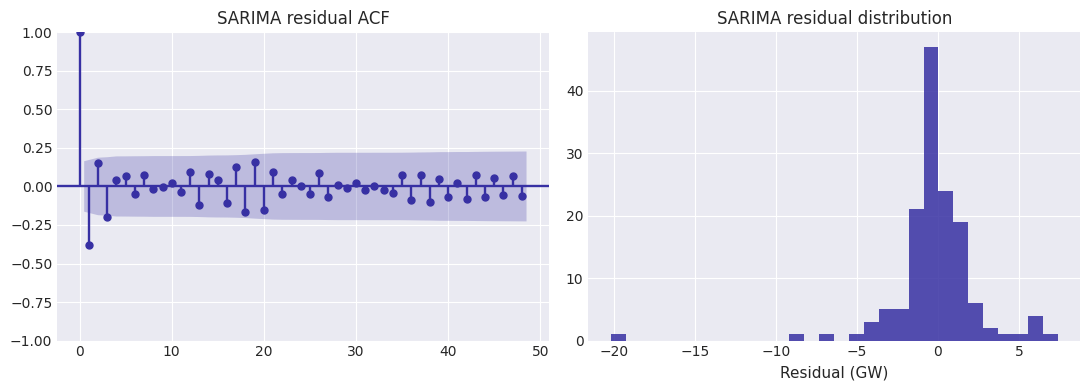

    lb_stat  lb_pvalue
12  34.3264     0.0006
24  57.6476     0.0001
Ljung-Box at lag 24 p-value: 0.0001


In [15]:
# Residual diagnostics for the selected model: an ACF plot, a histogram and the
# Ljung-Box test on the first 24 lags.
sarima_model = sarima_best["model"]
resid = sarima_model.resid.iloc[SEASON_LENGTH:]   # drop the differencing warm-up

fig, axes = plt.subplots(1, 2, figsize=(STYLE.figsize[0], 4))
plot_acf(resid, ax=axes[0], lags=48)
axes[0].set_title(styled_title("SARIMA residual ACF"))
axes[1].hist(resid, bins=30, color=STYLE.palette["primary"], alpha=0.85)
axes[1].set_title(styled_title("SARIMA residual distribution"))
axes[1].set_xlabel("Residual (GW)")
fig.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
print(lb.round(4))
print("Ljung-Box at lag 24 p-value:", round(float(lb['lb_pvalue'].iloc[-1]), 4))


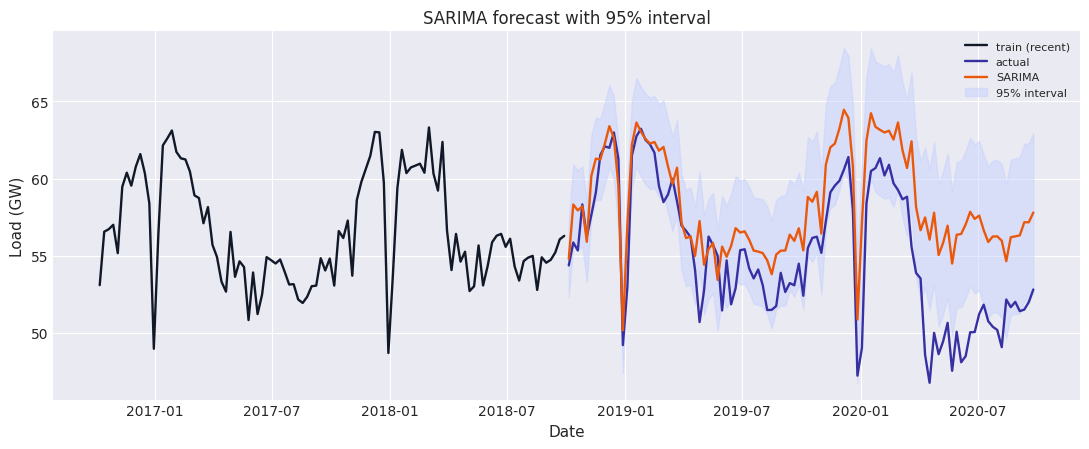

SARIMA metrics: {'MAE': np.float64(3.2219), 'RMSE': np.float64(3.9879), 'MASE': np.float64(2.3263), 'Bias': np.float64(3.1028)}
SARIMA 95% interval coverage: 0.721


In [16]:
# The 104-week forecast with a 95% prediction interval.
sarima_fc = sarima_model.get_forecast(steps=TEST_WEEKS)
sarima_mean = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int(alpha=0.05)
sarima_mean.index = ytest.index
sarima_ci.index = ytest.index
pred["sarima"] = pd.Series(sarima_mean.values, index=ytest.index)

sarima_lo = sarima_ci.iloc[:, 0].values
sarima_hi = sarima_ci.iloc[:, 1].values

fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.plot(ytrain.index[-104:], ytrain.values[-104:], color=STYLE.palette["actual"],
        label="train (recent)")
ax.plot(ytest.index, ytest.values, color=STYLE.palette["primary"], label="actual")
ax.plot(ytest.index, pred["sarima"].values, color=STYLE.palette["warm"], label="SARIMA")
ax.fill_between(ytest.index, sarima_lo, sarima_hi, color=STYLE.palette["band"],
                alpha=0.5, label="95% interval")
ax.set_title(styled_title("SARIMA forecast with 95% interval"))
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

sarima_metrics = tally(ytest.values, pred["sarima"].values)
sarima_cov = coverage(ytest.values, sarima_lo, sarima_hi)
print("SARIMA metrics:", {k: round(v, 4) for k, v in sarima_metrics.items()})
print("SARIMA 95% interval coverage:", round(sarima_cov, 3))


## **Block IV  SARIMAX with temperature (Part 4)**

In [ ]:
def _synthetic_daily_temp(index):

    day_of_year = index.dayofyear.values
    base = 9.5 - 9.0 * np.cos(2 * np.pi * (day_of_year - 20) / 365.25)
    rng = np.random.default_rng(GLOBAL_SEED)
    noise = rng.normal(0, 1.4, size=len(index))
    return pd.Series(base + noise, index=index, name="temp_mean")


def _load_daily_temperature(start, end):

    start_s, end_s = str(start.date()), str(end.date())
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 52.52, "longitude": 13.405,
        "start_date": start_s, "end_date": end_s,
        "daily": "temperature_2m_mean", "timezone": "Europe/Berlin",
    }
    try:
        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()
        payload = resp.json()["daily"]
        frame = pd.DataFrame({
            "time": pd.to_datetime(payload["time"]),
            "temp_mean": payload["temperature_2m_mean"],
        }).set_index("time")
        frame.to_csv(TEMP_CACHE)
        return frame["temp_mean"], "open-meteo"
    except Exception:
        pass
    if os.path.exists(TEMP_CACHE):
        cached = pd.read_csv(TEMP_CACHE, parse_dates=[0], index_col=0)
        # The cache may store a mean column or only min/max, from which a mean is derived.
        if "temp_mean" in cached.columns:
            mean_series = cached["temp_mean"]
        else:
            mm = [c for c in cached.columns if "temperature" in c]
            mean_series = cached[mm].mean(axis=1)
        mean_series.name = "temp_mean"
        return mean_series.loc[start_s:end_s], "cache"
    idx = pd.date_range(start, end, freq="D")
    return _synthetic_daily_temp(idx), "synthetic-proxy"


def exog_block(weekly_index, daily_temp):
    # This function turns a daily temperature series into a weekly exogenous frame of mean
    # temperature and heating and cooling degree days, aligned to the weekly target index.
    hdd = np.clip(HDD_BASE - daily_temp, 0, None)
    cdd = np.clip(daily_temp - CDD_BASE, 0, None)
    daily_frame = pd.DataFrame({"temp_mean": daily_temp, "hdd": hdd, "cdd": cdd})
    weekly = daily_frame.resample(WEEK_ANCHOR).mean()
    weekly = weekly.reindex(weekly_index).interpolate().bfill().ffill()
    return weekly


daily_temp, temp_source = _load_daily_temperature(
    weekly_load.index.min() - pd.Timedelta(days=10), weekly_load.index.max())
print("Temperature source:", temp_source)

exog_weekly = exog_block(weekly_load.index, daily_temp)
print("Exogenous columns:", list(exog_weekly.columns))
exog_weekly.tail(3).round(3)


Temperature source: open-meteo
Exogenous columns: ['temp_mean', 'hdd', 'cdd']


,temp_mean,hdd,cdd
utc_timestamp,,,
2020-09-11,15.914,0.200,0.0
2020-09-18,18.114,0.400,0.0
2020-09-25,16.243,0.343,0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


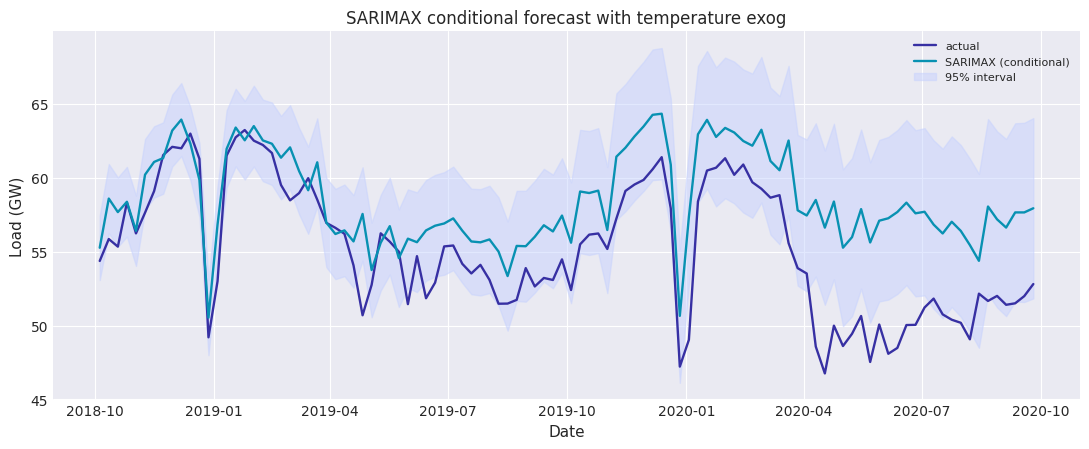

SARIMAX metrics: {'MAE': np.float64(3.4442), 'RMSE': np.float64(4.2528), 'MASE': np.float64(2.4868), 'Bias': np.float64(3.3423)}
SARIMAX 95% interval coverage: 0.731


In [18]:
# The exogenous features are shifted by one week before use so a week's forecast never
# sees its own contemporaneous temperature; this is the leakage guard. The SARIMAX model
# reuses the SARIMA order chosen by AIC.
exog_shifted = exog_weekly.shift(1).bfill()
exog_train = exog_shifted.iloc[:-TEST_WEEKS]
exog_test = exog_shifted.iloc[-TEST_WEEKS:]

sarimax_model = SARIMAX(
    ytrain, order=sarima_best["order"], seasonal_order=SEASONAL_ORDER,
    exog=exog_train, enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

sarimax_fc = sarimax_model.get_forecast(steps=TEST_WEEKS, exog=exog_test)
sarimax_mean = pd.Series(sarimax_fc.predicted_mean.values, index=ytest.index)
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)
sarimax_lo = sarimax_ci.iloc[:, 0].values
sarimax_hi = sarimax_ci.iloc[:, 1].values
pred["sarimax"] = sarimax_mean

fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.plot(ytest.index, ytest.values, color=STYLE.palette["primary"], label="actual")
ax.plot(ytest.index, pred["sarimax"].values, color=STYLE.palette["cool"],
        label="SARIMAX (conditional)")
ax.fill_between(ytest.index, sarimax_lo, sarimax_hi, color=STYLE.palette["band"],
                alpha=0.5, label="95% interval")
ax.set_title(styled_title("SARIMAX conditional forecast with temperature exog"))
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

sarimax_metrics = tally(ytest.values, pred["sarimax"].values)
sarimax_cov = coverage(ytest.values, sarimax_lo, sarimax_hi)
print("SARIMAX metrics:", {k: round(v, 4) for k, v in sarimax_metrics.items()})
print("SARIMAX 95% interval coverage:", round(sarimax_cov, 3))


## **Block V  Feature-based machine learning (Part 5)**

In [19]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import holidays as holidays_pkg

# Weekly German holiday counts are a valid future covariate because the calendar is known
# in advance.
de_holidays = holidays_pkg.Germany(years=range(2014, 2022))


def _holiday_count_for_week(week_end):
    # This helper counts public holidays in the seven days ending on the week label.
    days = pd.date_range(week_end - pd.Timedelta(days=6), week_end, freq="D")
    return int(sum(1 for d in days if d.date() in de_holidays))


def build_supervised(target, exog, lags=FEATURE_LAGS, rolls=ROLLING_WINDOWS):
    # This function assembles the feature matrix. Calendar and holiday terms are known at
    # the origin; lag, rolling and temperature terms are shifted so no future value leaks.
    frame = pd.DataFrame(index=target.index)
    woy = target.index.isocalendar().week.astype(int).values
    frame["woy_sin"] = np.sin(2 * np.pi * woy / 52.0)
    frame["woy_cos"] = np.cos(2 * np.pi * woy / 52.0)
    frame["month"] = target.index.month
    frame["holiday_count"] = [_holiday_count_for_week(t) for t in target.index]
    # Temperature features are shifted by one week to match the leakage guard used above.
    for col in exog.columns:
        frame[col] = exog[col].shift(1).values
    for lag in lags:
        frame[f"lag_{lag}"] = target.shift(lag)
    for win in rolls:
        frame[f"roll_{win}"] = target.shift(1).rolling(win).mean()
    frame["target"] = target.values
    return frame


supervised = build_supervised(weekly_load, exog_weekly).dropna()
feature_cols = [c for c in supervised.columns if c != "target"]

train_tbl = supervised.iloc[:-TEST_WEEKS]
Xtrain = train_tbl[feature_cols]
ytrain_ml = train_tbl["target"]
print("Feature columns:", feature_cols)
print("Supervised training rows:", len(train_tbl))


Feature columns: ['woy_sin', 'woy_cos', 'month', 'holiday_count', 'temp_mean', 'hdd', 'cdd', 'lag_1', 'lag_4', 'lag_13', 'lag_52', 'roll_8', 'roll_26']
Supervised training rows: 143


In [20]:
def forest_regress(X, y, seed=GLOBAL_SEED):
    # This function fits the primary RandomForest and the secondary HistGradientBoosting
    # regressor and returns both so their forecasts can be compared.
    rf = RandomForestRegressor(n_estimators=400, max_depth=None, random_state=seed, n_jobs=-1)
    rf.fit(X, y)
    hgb = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=seed)
    hgb.fit(X, y)
    return {"random_forest": rf, "hist_gbr": hgb}


def recursive_roll(models, history, exog, test_index, lags=FEATURE_LAGS, rolls=ROLLING_WINDOWS):
    # This function forecasts the test window recursively for each fitted model. After each
    # step the prediction is appended to the running history so the next lag and rolling
    # feature are built from predicted, not actual, future values.
    out = {name: [] for name in models}
    for name, model in models.items():
        series = history.copy()
        for stamp in test_index:
            woy = int(pd.Timestamp(stamp).isocalendar().week)
            row = {
                "woy_sin": np.sin(2 * np.pi * woy / 52.0),
                "woy_cos": np.cos(2 * np.pi * woy / 52.0),
                "month": pd.Timestamp(stamp).month,
                "holiday_count": _holiday_count_for_week(pd.Timestamp(stamp)),
            }
            for col in exog.columns:
                row[col] = exog[col].shift(1).reindex([stamp]).ffill().iloc[0]
            for lag in lags:
                row[f"lag_{lag}"] = series.iloc[-lag]
            for win in rolls:
                row[f"roll_{win}"] = series.iloc[-win:].mean()
            x_row = pd.DataFrame([row])[feature_cols]
            yhat = float(model.predict(x_row)[0])
            out[name].append(yhat)
            series = pd.concat([series, pd.Series([yhat], index=[stamp])])
    return {name: pd.Series(vals, index=test_index) for name, vals in out.items()}


ml_models = forest_regress(Xtrain, ytrain_ml)
ml_forecasts = recursive_roll(ml_models, ytrain.copy(), exog_weekly, ytest.index)
pred["random_forest"] = ml_forecasts["random_forest"]
pred["hist_gbr"] = ml_forecasts["hist_gbr"]

for name in ["random_forest", "hist_gbr"]:
    print(name, {k: round(v, 4) for k, v in tally(ytest.values, pred[name].values).items()})


random_forest {'MAE': np.float64(2.2803), 'RMSE': np.float64(2.9699), 'MASE': np.float64(1.6465), 'Bias': np.float64(1.9132)}
hist_gbr {'MAE': np.float64(2.6058), 'RMSE': np.float64(3.3567), 'MASE': np.float64(1.8815), 'Bias': np.float64(2.2874)}


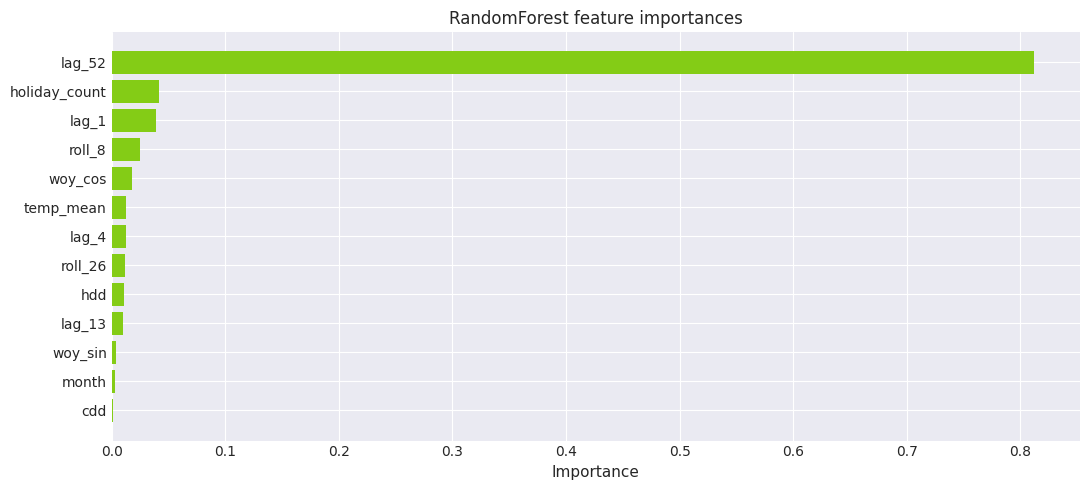

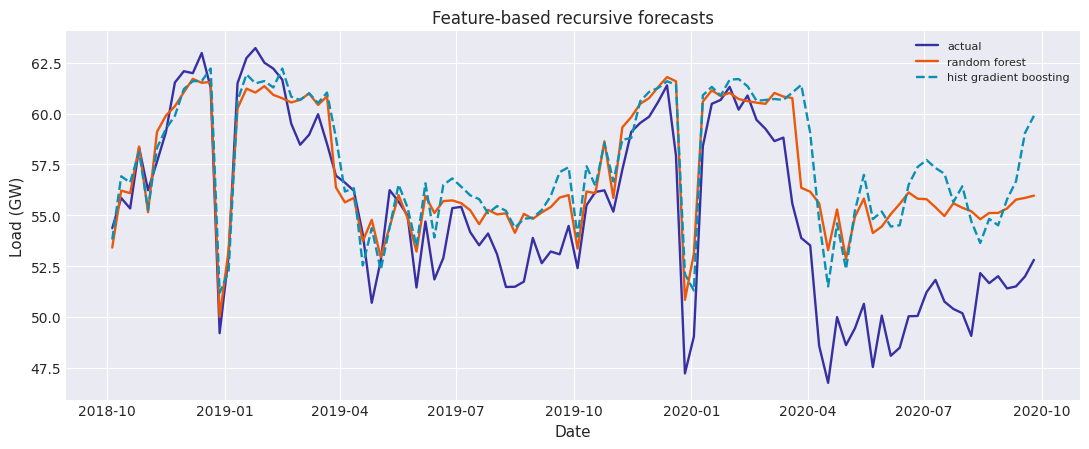

In [21]:
# The RandomForest feature importances show which signals the model leans on.
rf = ml_models["random_forest"]
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(STYLE.figsize[0], 5))
ax.barh(importance.index, importance.values, color=STYLE.palette["accent"])
ax.set_title(styled_title("RandomForest feature importances"))
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.plot(ytest.index, ytest.values, color=STYLE.palette["primary"], label="actual")
ax.plot(ytest.index, pred["random_forest"].values, color=STYLE.palette["warm"],
        label="random forest")
ax.plot(ytest.index, pred["hist_gbr"].values, color=STYLE.palette["cool"],
        linestyle="--", label="hist gradient boosting")
ax.set_title(styled_title("Feature-based recursive forecasts"))
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## **Block VI  LSTM on hourly demand (Part 6)**

In [22]:
# The LSTM block is optional. If TensorFlow is missing the notebook records that the
# block was skipped and moves on without failing.
LSTM_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(GLOBAL_SEED)
    print("TensorFlow", tf.__version__, "available; the LSTM block will run.")
except Exception as exc:
    LSTM_AVAILABLE = False
    print("TensorFlow is not available; the LSTM block is skipped. Reason:", exc)


TensorFlow 2.20.0 available; the LSTM block will run.


In [23]:
def window_stack(values, look_back=LOOK_BACK):
    # This function frames a one-dimensional array into overlapping (look_back -> next)
    # supervised windows for sequence training.
    X, y = [], []
    for i in range(len(values) - look_back):
        X.append(values[i:i + look_back])
        y.append(values[i + look_back])
    X = np.asarray(X).reshape(-1, look_back, 1)
    y = np.asarray(y)
    return X, y


if LSTM_AVAILABLE:
    # The hourly series is split in time; scaling uses training statistics only so no test
    # information leaks into the scaler.
    hourly_values = hourly_load.values.astype("float32")
    weeks_of_hours = TEST_WEEKS * 168
    hourly_train = hourly_values[:-weeks_of_hours]
    hourly_test = hourly_values[-weeks_of_hours:]

    train_mean = hourly_train.mean()
    train_std = hourly_train.std()
    scaled_train = (hourly_train - train_mean) / train_std

    Xh, yh = window_stack(scaled_train, LOOK_BACK)
    val_cut = int(len(Xh) * 0.85)
    Xtr, ytr = Xh[:val_cut], yh[:val_cut]
    Xval, yval = Xh[val_cut:], yh[val_cut:]
    print("LSTM training windows:", Xtr.shape, "| validation windows:", Xval.shape)


LSTM training windows: (27846, 168, 1) | validation windows: (4914, 168, 1)


In [24]:
if LSTM_AVAILABLE:
    def build_lstm_m7(units, dropout, lr):
        # This helper builds a compact single-layer LSTM regressor for a given
        # hyperparameter triple.
        model = Sequential([
            Input(shape=(LOOK_BACK, 1)),
            LSTM(units),
            Dropout(dropout),
            Dense(1),
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    # The sweep grid. EPOCHS is kept moderate; early stopping halts training when
    # validation loss stops improving.
    UNIT_GRID = [48, 96]
    DROPOUT_GRID = [0.0, 0.2]
    LR_GRID = [5e-4]
    EPOCHS = 6

    sweep_rows = []
    best_lstm = {"val_loss": np.inf, "model": None, "config": None}
    stopper = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    for units in UNIT_GRID:
        for dropout in DROPOUT_GRID:
            for lr in LR_GRID:
                tf.keras.backend.clear_session()
                tf.random.set_seed(GLOBAL_SEED)
                model = build_lstm_m7(units, dropout, lr)
                hist = model.fit(
                    Xtr, ytr, validation_data=(Xval, yval),
                    epochs=EPOCHS, batch_size=256, verbose=0, callbacks=[stopper],
                )
                val_loss = float(min(hist.history["val_loss"]))
                sweep_rows.append({"units": units, "dropout": dropout, "lr": lr,
                                   "val_loss": val_loss})
                if val_loss < best_lstm["val_loss"]:
                    best_lstm = {"val_loss": val_loss, "model": model,
                                 "config": (units, dropout, lr)}
    sweep_table = pd.DataFrame(sweep_rows).sort_values("val_loss").reset_index(drop=True)
    print("Best LSTM config (units, dropout, lr):", best_lstm["config"],
          "| val_loss:", round(best_lstm["val_loss"], 5))
    sweep_table


Best LSTM config (units, dropout, lr): (48, 0.0, 0.0005) | val_loss: 0.01186


  rollout step 2000/17472 | 7.5 ms/step | remaining ~1.9 min
  rollout step 4000/17472 | 7.5 ms/step | remaining ~1.7 min
  rollout step 6000/17472 | 7.4 ms/step | remaining ~1.4 min
  rollout step 8000/17472 | 7.5 ms/step | remaining ~1.2 min
  rollout step 10000/17472 | 7.5 ms/step | remaining ~0.9 min
  rollout step 12000/17472 | 7.5 ms/step | remaining ~0.7 min
  rollout step 14000/17472 | 7.4 ms/step | remaining ~0.4 min
  rollout step 16000/17472 | 7.4 ms/step | remaining ~0.2 min
  rollout step 17472/17472 | 7.4 ms/step | remaining ~0.0 min
LSTM weekly metrics: {'MAE': np.float64(3.7926), 'RMSE': np.float64(4.4029), 'MASE': np.float64(2.7384), 'Bias': np.float64(0.5811)}


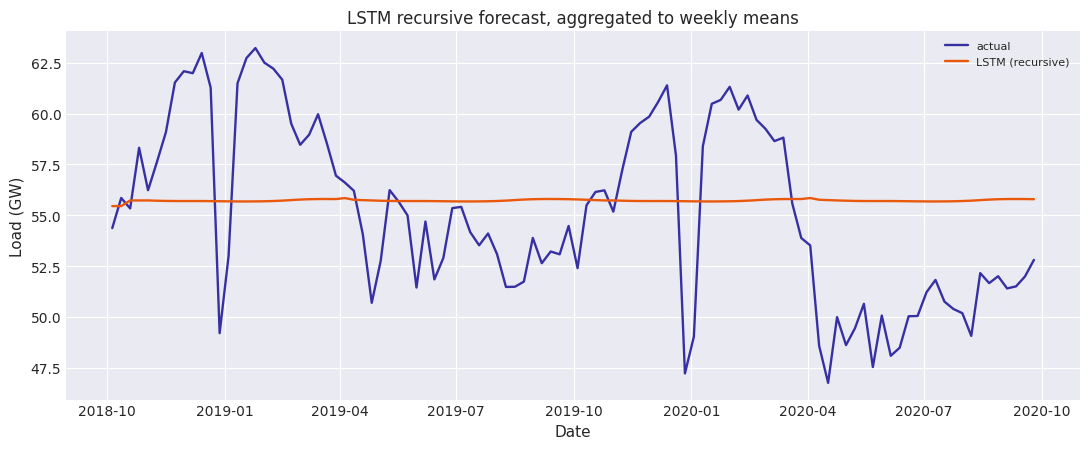

In [25]:
if LSTM_AVAILABLE:
    # The forecast is a genuine recursive rollout: the model is seeded with the last
    # training window and its own predictions are fed back for the full test horizon.
    # The per-step inference goes through a compiled tf.function step instead of
    # model.predict, which removes the per-call overhead and makes the 17,472-step
    # rollout finish in well under a minute rather than hours. A progress line is
    # printed every 2,000 steps so the loop never looks frozen.
    model = best_lstm["model"]

    @tf.function(input_signature=[tf.TensorSpec([1, LOOK_BACK, 1], tf.float32)])
    def _roll_step_m7(x):
        # The fixed input signature compiles the step once; every later call reuses
        # the same graph, so each rollout step costs only a few milliseconds.
        return model(x, training=False)

    window = np.asarray(scaled_train[-LOOK_BACK:], dtype="float32").reshape(1, LOOK_BACK, 1)
    total_steps = len(hourly_test)
    rollout_scaled = np.empty(total_steps, dtype="float32")
    roll_start = time.time()
    for step in range(total_steps):
        yhat = float(_roll_step_m7(tf.constant(window)).numpy()[0, 0])
        rollout_scaled[step] = yhat
        # The window slides by one hour and the prediction is fed back in at the end.
        window = np.concatenate(
            [window[:, 1:, :], np.full((1, 1, 1), yhat, dtype="float32")], axis=1)
        if (step + 1) % 2000 == 0 or (step + 1) == total_steps:
            per_step = (time.time() - roll_start) / (step + 1)
            print(f"  rollout step {step + 1}/{total_steps} "
                  f"| {per_step * 1000:.1f} ms/step "
                  f"| remaining ~{per_step * (total_steps - step - 1)/60:.1f} min",
                  flush=True)
    rollout = rollout_scaled.astype("float64") * train_std + train_mean

    # The hourly rollout is aggregated to weekly means on the test index for scoring.
    test_hours_index = hourly_load.index[-weeks_of_hours:]
    hourly_fc = pd.Series(rollout, index=test_hours_index)
    lstm_weekly = shape_weekly(hourly_fc).reindex(ytest.index).interpolate().bfill().ffill()
    pred["lstm"] = lstm_weekly

    lstm_metrics = tally(ytest.values, pred["lstm"].values)
    print("LSTM weekly metrics:", {k: round(v, 4) for k, v in lstm_metrics.items()})

    fig, ax = plt.subplots(figsize=STYLE.figsize)
    ax.plot(ytest.index, ytest.values, color=STYLE.palette["primary"], label="actual")
    ax.plot(ytest.index, pred["lstm"].values, color=STYLE.palette["warm"],
            label="LSTM (recursive)")
    ax.set_title(styled_title("LSTM recursive forecast, aggregated to weekly means"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Load (GW)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("LSTM block skipped; no LSTM forecast added to the comparison.")


## **Block VIII — Consolidated comparison (Part 8)**

In [26]:
# The consolidated metrics table for every model that produced a forecast.
metric_rows = {}
for name, series in pred.items():
    metric_rows[name] = tally(ytest.values, series.values)
metrics_df = pd.DataFrame(metric_rows).T

# The MASE ratio against seasonal naive; below one means the model beats the benchmark.
sn_mase = metrics_df.loc["seasonal_naive", "MASE"]
metrics_df["MASE_ratio_vs_seasonal_naive"] = metrics_df["MASE"] / sn_mase
metrics_df = metrics_df.sort_values("MASE")

metrics_df.to_csv("outputs/metrics/model_comparison.csv")
pd.DataFrame(pred).to_csv("outputs/forecasts/all_forecasts.csv")
metrics_df.round(4)


,MAE,RMSE,MASE,Bias,MASE_ratio_vs_seasonal_naive
random_forest,2.2803,2.9699,1.6465,1.9132,0.9889
seasonal_naive,2.3060,3.0450,1.6650,1.7368,1.0000
hist_gbr,2.6058,3.3567,1.8815,2.2874,1.1300
sarima,3.2219,3.9879,2.3263,3.1028,1.3972
sarimax,3.4442,4.2528,2.4868,3.3423,1.4936
mean,3.7855,4.3960,2.7332,0.5555,1.6416
lstm,3.7926,4.4029,2.7384,0.5811,1.6447
naive,3.8906,4.5074,2.8092,1.1402,1.6872
drift,4.0593,4.7229,2.9310,1.5092,1.7603


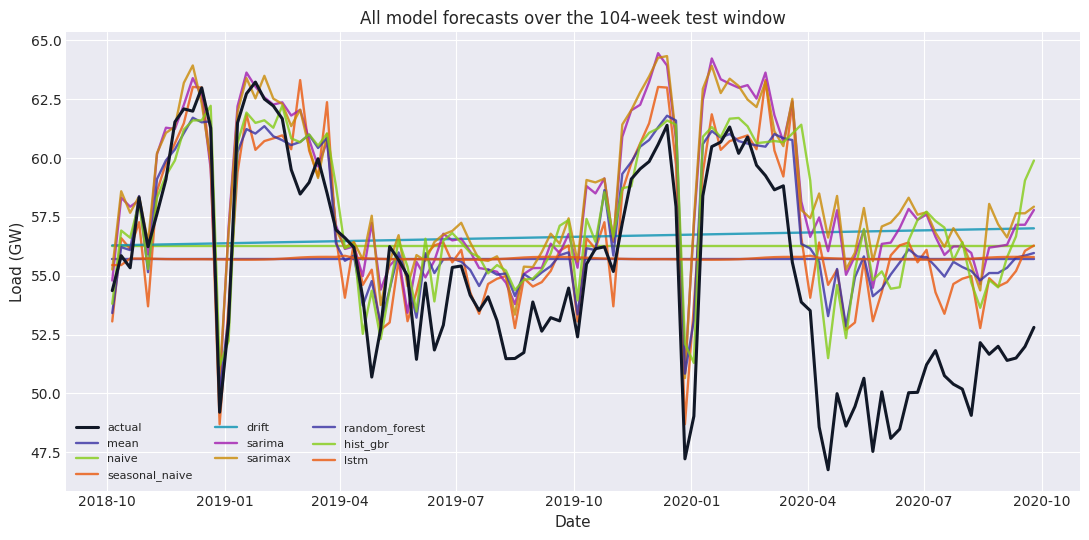

Master figure saved to outputs/figures/forecast_comparison.png


In [27]:
# The master comparison plot overlays every model against the actual test series.
fig, ax = plt.subplots(figsize=(STYLE.figsize[0], 5.5))
ax.plot(ytest.index, ytest.values, color=STYLE.palette["actual"], linewidth=2.2,
        label="actual", zorder=5)
for name, series in pred.items():
    ax.plot(ytest.index, series.values, alpha=0.8, label=name)
ax.set_title(styled_title("All model forecasts over the 104-week test window"))
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig("outputs/figures/forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Master figure saved to outputs/figures/forecast_comparison.png")


In [28]:
# Regime diagnostics: MAE over the festive ISO weeks (52, 1, 2) and over the five
# hottest and five coldest test weeks, so we can see where each model struggles.
iso_weeks = ytest.index.isocalendar().week.astype(int)
festive_mask = iso_weeks.isin([52, 1, 2]).values

weekly_temp_test = exog_weekly["temp_mean"].reindex(ytest.index)
coldest = weekly_temp_test.nsmallest(5).index
hottest = weekly_temp_test.nlargest(5).index


def _regime_mae(series, mask):
    a = ytest.values[mask]
    f = series.values[mask]
    return float(np.mean(np.abs(f - a)))


regime_rows = {}
for name, series in pred.items():
    regime_rows[name] = {
        "festive_MAE": _regime_mae(series, festive_mask),
        "coldest5_MAE": float(np.mean(np.abs(series.reindex(coldest).values - ytest.reindex(coldest).values))),
        "hottest5_MAE": float(np.mean(np.abs(series.reindex(hottest).values - ytest.reindex(hottest).values))),
    }
regime_df = pd.DataFrame(regime_rows).T.sort_values("festive_MAE")
regime_df.to_csv("outputs/metrics/regime_diagnostics.csv")
regime_df.round(4)


,festive_MAE,coldest5_MAE,hottest5_MAE
seasonal_naive,1.7520,2.3041,1.2450
random_forest,2.0346,1.7469,1.8931
hist_gbr,2.2129,1.3440,1.7017
sarima,3.5838,2.0544,1.9701
sarimax,3.6530,2.5052,2.5117
lstm,5.4713,6.5962,2.4399
mean,5.4723,6.5944,2.3981
naive,5.6671,6.2435,2.9828
drift,5.7562,6.2576,3.4383


## **Block IX  Repository notes (Part 9)**

This notebook is the analysis entry point of an identity-free, reproducible repository.
It runs top to bottom from a fresh kernel, reads its data through relative paths, sets
every random seed, and wraps optional dependencies so a missing package degrades
gracefully rather than aborting the run.

**How to run.** Install the packages in the environment cell (or `pip install -r
requirements.txt`), place `time_series_60min_singleindex.csv` in the notebook folder (or
let the acquisition cell download it), then run all cells. Outputs are written under
`outputs/` as `forecasts/all_forecasts.csv`, `metrics/model_comparison.csv`,
`metrics/regime_diagnostics.csv` and `figures/forecast_comparison.png`.

**Reproducibility.** The single `GLOBAL_SEED` drives NumPy, scikit-learn and TensorFlow;
the train/test split is strictly time-ordered; and the SARIMA grid, feature set and LSTM
sweep are fixed in the constants cell. The README and `requirements.txt` accompany this
notebook in the repository.
